In [3]:
!pip install cvxpy[OSQP,ECOS] --upgrade
!pip install gurobipy>=10  # install gurobipy, if not already installed

import numpy as np
import gurobipy as gp
import matplotlib.pyplot as plt
import pandas as pd
import cvxpy as cp
import time

# Create an environment with your WLS license
params = {
"WLSACCESSID": 'bd6082d8-df30-497b-86f3-f189f173114f',
"WLSSECRET": '33a99b27-d33d-4640-ab8e-6b4db5d020bd',
"LICENSEID": 2446748,
}
env = gp.Env(params=params)

print("- cvxpy version:", cp.__version__, "-")
print("- cvxpy installed solvers:", cp.installed_solvers())

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2446748
Academic license 2446748 - for non-commercial use only - registered to tn___@columbia.edu
- cvxpy version: 1.4.2 -
- cvxpy installed solvers: ['CLARABEL', 'CVXOPT', 'ECOS', 'ECOS_BB', 'GLPK', 'GLPK_MI', 'GUROBI', 'OSQP', 'SCIPY', 'SCS']


In [4]:
def eps_approx_eq(N, M, D, B, p, x, E2Tol=1e-6, E3Tol=1e-6, report_all=False, ignore_print=False):

    def equal_budget_eps(B, p, x):
        B_ = np.sum(p * x, axis=1)
        eps1 = max(1 - min(B_ / B), 1 - 1 / max(B_ / B))

        return eps1

    def optimal_bundle_eps(N, D, p, x):
        eps2 = 0
        for i in range(N):
            beta = max(p / D[i])
            min_disuti = sum(p * x[i]) / beta
            eps_i = 1 - min_disuti / sum(D[i] * x[i])
            if eps_i > eps2:
                eps2 = eps_i

        return eps2

    def market_clearance_eps(M, x):
        eps3 = max(np.abs(np.sum(x, axis=0) - np.ones(M)))

        return eps3

    eps1 = equal_budget_eps(B, p, x)
    eps2 = optimal_bundle_eps(N, D, p, x)
    eps3 = market_clearance_eps(M, x)

    if report_all:
        if not ignore_print:
            print()
            print("===============================================================")
            print("(E1) Equal Budget \t\t (E2) Optimal Bundle \t\t (E3) Market Clearance")
            print("---------------------------------------------------------------")
            print(f"{eps1} \t\t {eps2} \t\t {eps3}")
            print("---------------------------------------------------------------")

    if eps2 > E2Tol:
        return f"(E2 - optimal_bundle) is not exactly satisfied (eps2 = {eps2})."

    if eps3 > E3Tol:
        return f"(E3 - market_clearance) is not exactly satisfied (eps3 = {eps3})."

    return eps1

In [5]:
def polytope_dual(N, M, D, B):
    A = list()
    # use Gurobi, not include the nonnegative constraints
    for i in range(N):
        D_i_T = np.zeros(shape=(M, N))
        D_i_T[:, i] = - D[i]
        A_i = np.concatenate([np.identity(M), D_i_T], axis=1)
        A.append(A_i)
    A = np.concatenate(A, axis=0)
    b = np.zeros(shape=(M * N))
    C = np.concatenate([np.ones(M), np.zeros(N)]).reshape(1, -1)
    d = np.array(sum(B)).reshape(1, )

    return A, b, C, d

def feasible_point(M, N, D, B, random=False, random_seed=2024):  ###
    if random:
        np.random.seed(random_seed)
        p_0 = np.random.uniform(size=M)
        p_0 = p_0 / sum(p_0) * sum(B)
        beta_0 = np.amax(p_0 / D, axis=1) + np.random.uniform(size=N)
    else:
        p_0 = (sum(B) / M) * np.ones(shape=M)
        beta_0 = np.amax(p_0 / D, axis=1)

    return p_0, beta_0

def LMO(c, A, b, C=None, d=None, return_dual=False):
    m = gp.Model(env=env)
    N = len(c)

    M = A.shape[1] - len(c)
    p = m.addMVar(M)
    beta = m.addMVar(len(c))

    m.setObjective(c @ beta)
    m.addConstr(A[:, :M] @ p + A[:, M:] @ beta <= b)
    if C is not None and d is not None:
        m.addConstr(C[:, :M] @ p + C[:, M:] @ beta == d)
    # m.PStart = x0

    m.Params.LogToConsole = 0
    # m.Params.Method = 1
    m.optimize()

    if return_dual:
        return p.X, beta.X, np.array(m.Pi)
    else:
        return p.X, beta.X

def GFW(N, M, D, B, return_eq=False):  # Greedy Frank Wolfe

    # create the dual polyhedron
    A, b, C, d = polytope_dual(N, M, D, B)

    # initialize
    MAX_NUM_ITER = 50
    num_LMO_a1, num_LMO_e = MAX_NUM_ITER, MAX_NUM_ITER
    solved_a1, solved_e = False, False
    running_time_a1, running_time_e = None, None

    # counters
    num_LMO = 0
    running_time = 0

    # analysis
    solve_LP_time = 0
    solve_LP_num = 0

    p, beta = feasible_point(M, N, D, B)
    beta_ = beta  # 'beta_' keeps the last beta values

    for k in range(MAX_NUM_ITER):

        # main
        LP_start = GFW_start = time.time()

        p, beta, gamma = LMO(B / beta, A, b, C, d, return_dual=True)

        solve_LP_time += time.time() - LP_start
        solve_LP_num += 1
        num_LMO += 1

        x = -gamma[: N * M].reshape(N, M)
        x = sum(B) / sum(B * beta / beta_) * x
        beta_ = beta

        running_time += time.time() - GFW_start

        # evaluation
        eps = eps_approx_eq(N, M, D, B, p, x, ignore_print=True)

        if type(eps) is str:
            print(eps)
            break  # terminate the algorithm

        if type(eps) is not str:
            if eps <= 0.1 and num_LMO_a1 == MAX_NUM_ITER:  # the second condition ensures that 'num_LMO_1' has not been updated
                solved_a1 = True
                num_LMO_a1 = num_LMO
                running_time_a1 = running_time

            if eps <= 1e-6:
                solved_e = True
                num_LMO_e = num_LMO
                running_time_e = running_time
                break

    # print("Average LP solving time:", solve_LP_time / solve_LP_num)
    if return_eq:
        if solved_e:
            print("p:\n", np.round(p, 3))
            print("x:\n", np.round(x, 3))
            print("u:\n", np.round(B / beta, 3))
    return num_LMO_a1, num_LMO_e, solved_a1, solved_e, running_time_a1, running_time_e

In [ ]:
def poly_ext_primal(N, M, D, B):
    A = list()
    A.append(np.zeros(shape=(N, N + M * N)))
    for i in range(N):
        A[0][i, i] = -1
        A[0][i, N + i * M: N + i * M + M] = D[i]
    # show add x is nonnegative constraint when solving QP using some solver
    A = np.concatenate(A, axis=0)
    b = np.zeros(N)
    C = np.zeros(shape=(M, N + M * N))
    for j in range(M):
        C[j, N + j: N + M * N: M] = 1
    d = np.ones(M)

    return A, b, C, d

def QMO(ux0, N, A, b, C=None, d=None, solver='OSQP'):
    if solver == 'OSQP':
        ux = cp.Variable(len(ux0), nonneg=True)
        obj = cp.Minimize(sum((ux[:N] - ux0[:N]) ** 2))
        constraints = [A @ ux <= b, ]
        if C is not None and d is not None:
            constraints.append(C @ ux == d)
        prob = cp.Problem(obj, constraints)
        try:
            prob.solve(solver='OSQP', max_iter=100000, verbose=False)
        except:
            return ux0, np.float64(10000000)  # should change this
        # print(prob.status)

        return ux.value, prob.value

    elif solver == 'GUROBI':
        m = gp.Model(env=env)

        m.Params.LogToConsole = 0
        m.Params.FeasibilityTol = 1e-9
        m.Params.OptimalityTol = 1e-9
        m.Params.BarConvTol = 0.0
        m.Params.BarCorrectors = 10000

        u = m.addMVar(N)
        x = m.addMVar(A.shape[1] - N)
        u0 = ux0[:N]
        m.setObjective((u - u0) @ (u - u0))
        m.addConstr(A[:, :N] @ u + A[:, N:] @ x <= b)
        if C is not None and d is not None:
            m.addConstr(C[:, :N] @ u + C[:, N:] @ x == d)

        m.optimize()

        obj = m.getObjective()

        return np.concatenate([u.X, x.X]), obj.getValue()

def print_quality_QMO(x_value, obj_value, N, A, b, C=None, d=None, solver_name="Unnamed"):
    feasibility_tol = np.maximum(A @ x_value - b, 0)
    if C is not None and d is not None:
        feasibility_tol_eq = np.abs(C @ x_value - d)
    print("---")
    print("Solver Name:", solver_name)
    print("Max Feasibility Tolerance:", max(max(feasibility_tol), max(feasibility_tol_eq)))
    print("Objective Value (Min Dist)", obj_value)

def find_X(N, M, u, A, b, C=None, d=None):
    m = gp.Model(env=env)

    x = m.addMVar(N * M)
    eps = m.addVar()

    m.setObjective(eps)
    m.addConstr(A[:, N:] @ x - eps <= u)
    if C is not None and d is not None:
        m.addConstr(C[:, N:] @ x == d)

    m.Params.LogToConsole = 0
    m.Params.FeasibilityTol = 1e-9
    m.Params.OptimalityTol = 1e-9
    m.optimize()
    # m.printQuality()

    if eps.X <= 1e-12:  # high accuracy required on finding a feasible (or over-allocated) allocation
        return x.X.reshape(N, M)
    else:
        return "There is no feasible allocation corresponding to given disutility.", eps.X

def u_is_feasible(N, M, u, A, b, C=None, d=None):
    X = find_X(N, M, u, A, b, C, d)
    if type(X) is np.ndarray:
        return True, X
    else:
        return False, None

def EPM(N, M, D, B, QMO_solver='best', print_quality=False, print_progress=False, ignore_print=False, return_eq=False):

    # construct extended (u, x) polyhedral
    A, b, C, d = poly_ext_primal(N, M, D, B)

    # pick an initial (infeasible) point (near 0)
    u = u0 = np.amin(D, axis=1) / (N + 1) ** 2  # or / (N + 1)

    # initialize
    MAX_NUM_ITER = 50
    MAX_FEASIBILITY_TOL = 1e-6
    num_QMO_a1, num_QMO_e = MAX_NUM_ITER, MAX_NUM_ITER
    solved_a1, solved_e = False, False
    running_time_a1, running_time_e = None, None

    # counters
    num_QMO = 0
    running_time = 0

    # analysis
    solve_QP_time = 0
    solve_QP_num = 0

    for k in range(MAX_NUM_ITER):

        # main
        QP_start = EPM_start = time.time()

        # choose the solver which performs best on this iteration
        if QMO_solver == 'best':
            solver_list = ['OSQP', 'GUROBI', 'MOSEK']
            res_dict = {
                'solver': [],
                'feasibility tolerance (ineq)': [],
                'feasibility tolerance (eq)': [],
                'objective value': [],
                'feasible objective value': []
            }
            u_obj_list = []
            for solver in solver_list:
                u_, min_dist = QMO(np.concatenate([u, np.zeros(M * N)]),
                            N,
                            np.concatenate([A, np.concatenate([-np.identity(N), np.zeros((N, M * N))], axis=1)], axis=0),
                            np.concatenate([b, -u]),
                            C,
                            d,
                            solver=solver
                )

                feasibility_tol_ineq = np.maximum(A @ u_ - b, 0)
                if C is not None and d is not None:
                    feasibility_tol_eq = np.abs(C @ u_ - d)
                res_dict['solver'].append(solver)
                res_dict['feasibility tolerance (ineq)'].append(max(feasibility_tol_ineq))
                res_dict['feasibility tolerance (eq)'].append(max(feasibility_tol_eq))
                res_dict['objective value'].append(min_dist)
                if max(max(feasibility_tol_ineq), max(feasibility_tol_eq)) > MAX_FEASIBILITY_TOL:
                    res_dict['feasible objective value'].append(np.inf)  # only consider feasible solution
                else:
                    res_dict['feasible objective value'].append(min_dist)
                u_obj_list.append((u_, min_dist))
            # print(type(res_dict['objective value'][0]))
            res_dict[f'obj value vs {solver_list[0]}'] = res_dict['objective value'] - res_dict['objective value'][0]

            selected_solver = solver_list[np.argmin(res_dict['feasible objective value'])]
            u_, min_dist = u_obj_list[np.argmin(res_dict['feasible objective value'])]
            if print_quality:
                res_table = pd.DataFrame(res_dict)
                display(res_table)
                print(selected_solver)

        # choose one specific solver
        else:
            ux_, min_dist = QMO(np.concatenate([u, np.zeros(M * N)]),
                            N,
                            np.concatenate([A, np.concatenate([-np.identity(N), np.zeros((N, M * N))], axis=1)], axis=0),
                            np.concatenate([b, -u]),
                            C,
                            d,
                            solver=QMO_solver
            )
            solve_QP_time += time.time() - QP_start
            solve_QP_num += 1
            if print_quality:
                print_quality_QMO(u_, min_dist, N, A, b, C, d, solver_name=QMO_solver)

        u_, x = ux_[:N], ux_[N:].reshape(N, M)
        a = u_ - u
        a = N * a / sum(a * u_)
        u = 1 / a

        running_time += time.time() - EPM_start
        num_QMO += 1

        # evaluation
        c = a.reshape(-1, 1) * D
        p = np.amin(c, axis=0)
        try:
            eps = eps_approx_eq(N, M, D, B, p, x)
        except:
            print("--- Note ---")
            break

        next_u_is_feasible, x = u_is_feasible(N, M, u, A, b, C, d)

        if type(eps) is str and next_u_is_feasible:  # a, p are not precise, choose: report unsolved
            break
        if type(eps) is not str and eps > 1:
            break
        if type(eps) is not str:
            if eps <= 0.1 and num_QMO_a1 == MAX_NUM_ITER:
                solved_a1 = True
                num_QMO_a1 = num_QMO
                running_time_a1 = running_time
        if print_progress:
            print(eps)

        if next_u_is_feasible:
            c = a.reshape(-1, 1) * D
            p = np.amin(c, axis=0)
            if ignore_print:
                eps = eps_approx_eq(N, M, D, B, p, x, ignore_print=True)
            elif print_progress:
                eps = eps_approx_eq(N, M, D, B, p, x, report_all=True)
            else:
                eps = eps_approx_eq(N, M, D, B, p, x)

            if type(eps) is not str and eps <= 0.1 and num_QMO_a1 > num_QMO:
                solved_a1 = True
                num_QMO_a1 = num_QMO
                running_time_a1 = running_time

            if type(eps) is not str and eps <= 1e-5:
                solved_e = True
                num_QMO_e = num_QMO
                running_time_e = running_time

            if print_progress:
                print()
            break

    # print("Average QP solving time:", solve_QP_time / solve_QP_num)
    if return_eq:
        if solved_e:
            print("p:\n", np.round(p, 3))
            print("x:\n", np.round(x, 3))
            print("u:\n", np.round(u, 3))
    return num_QMO_a1, num_QMO_e, solved_a1, solved_e, running_time_a1, running_time_e

In [7]:
def run_GFW_vs_EPM(N, M, random_generation_method='uniform', num_seeds=10, num_iter_max_cap=100, running_time_max_cap=100, return_eq=False):
    seeds = range(num_seeds)  # set how many instances we want to try for one size
    num_LMO_list = [[], []]
    running_time_GFW_list = [[], []]
    num_ins_GFW_solved = [0, 0]
    data_GFW = {
        'size': f'N*M = {N}*{M}',
        'num-iter-a1': None,
        'num-iter-e': None,
        'solved-a1': None,
        'solved-e': None,
        'running-time-a1': None,
        'running-time-e': None,
    }
    num_QMO_list = [[], []]
    running_time_EPM_list = [[], []]
    num_ins_EPM_solved = [0, 0]
    data_EPM = {
        'size': f'N*M = {N}*{M}',
        'num-iter-a1': None,
        'num-iter-e': None,
        'solved-a1': None,
        'solved-e': None,
        'running-time-a1': None,
        'running-time-e': None,
    }

    for s in seeds:
        np.random.seed(s)
        if random_generation_method == 'randint':
            D = np.random.randint(low=1, high=101, size=(N, M))
        elif random_generation_method == 'uniform':
            D = np.random.uniform(size=(N, M))
        # d_buyers = np.abs(np.random.normal(size=N))
        # d_items = np.abs(np.random.normal(size=M))
        # d_buyers = np.abs(np.random.normal(size=N))
        # d_items = np.abs(np.random.normal(size=M))
        # D = np.maximum(d_buyers @ d_items.reshape(-1, 1) + 0.1 * np.random.uniform(size=(N, M)), 1e-3)
        B = np.ones(shape=N)

        # d_buyers = 0.1 * np.abs(np.random.randint(low=1, high=101, size=N))
        # d_items = 0.1 * np.abs(np.random.randint(low=1, high=101, size=M))
        # D = np.maximum(d_buyers @ d_items.reshape(-1, 1) + 0.1 * np.random.uniform(size=(N, M)), 1e-3)
        # B = np.ones(shape=N)

        '''
        Run the Greedy Frank Wolfe algorithm
        '''

        res_GFW = GFW(N, M, D, B, return_eq=return_eq)
        res_EPM = EPM(N, M, D, B, QMO_solver='GUROBI', ignore_print=True, return_eq=return_eq)

        for i in range(2):
            num_ins_GFW_solved[i] += res_GFW[2 + i]
            num_ins_EPM_solved[i] += res_EPM[2 + i]
            if res_GFW[2 + i]:
                num_LMO_list[i].append(res_GFW[i])
                running_time_GFW_list[i].append(res_GFW[4 + i])
            if res_EPM[2 + i]:
                num_QMO_list[i].append(res_EPM[i])
                running_time_EPM_list[i].append(res_EPM[4 + i])

    data_GFW['num-iter-a1'] = min(average(num_LMO_list[0]), num_iter_max_cap)
    data_GFW['num-iter-e'] = min(average(num_LMO_list[1]), num_iter_max_cap)
    data_GFW['solved-a1'] = num_ins_GFW_solved[0]
    data_GFW['solved-e'] = num_ins_GFW_solved[1]
    data_GFW['running-time-a1'] = min(average(running_time_GFW_list[0]), running_time_max_cap)
    data_GFW['running-time-e'] = min(average(running_time_GFW_list[1]), running_time_max_cap)

    data_EPM['num-iter-a1'] = min(average(num_QMO_list[0]), num_iter_max_cap)
    data_EPM['num-iter-e'] = min(average(num_QMO_list[1]), num_iter_max_cap)
    data_EPM['solved-a1'] = num_ins_EPM_solved[0]
    data_EPM['solved-e'] = num_ins_EPM_solved[1]
    data_EPM['running-time-a1'] = min(average(running_time_EPM_list[0]), running_time_max_cap)
    data_EPM['running-time-e'] = min(average(running_time_EPM_list[1]), running_time_max_cap)

    print(data_GFW)
    print(data_EPM)

    return data_GFW, data_EPM

In [ ]:
def average(lst):  # return the average of a list
    num_nonNone = 0
    sum = 0

    for e in lst:
        if e is not None:
            num_nonNone += 1
            sum += e

    if num_nonNone > 0:
        return sum / num_nonNone
    else:
        return np.inf

x = list()
i_y1, i_y2 = list(), list()
i_z1, i_z2 = list(), list()
s_y1, s_y2 = list(), list()
s_z1, s_z2 = list(), list()
r_y1, r_y2 = list(), list()
r_z1, r_z2 = list(), list()

for size in range(2, 103, 10):
    N = size
    M = 2 * size
    x.append(size)
    res_GFW, res_EPM = run_GFW_vs_EPM(N, M, random_generation_method='randint', num_seeds=10)
    i_y1.append(res_GFW['num-iter-a1'])
    s_y1.append(res_GFW['solved-a1'])
    r_y1.append(res_GFW['running-time-a1'])
    i_y2.append(res_GFW['num-iter-e'])
    s_y2.append(res_GFW['solved-e'])
    r_y2.append(res_GFW['running-time-e'])

    i_z1.append(res_EPM['num-iter-a1'])
    s_z1.append(res_EPM['solved-a1'])
    r_z1.append(res_EPM['running-time-a1'])
    i_z2.append(res_EPM['num-iter-e'])
    s_z2.append(res_EPM['solved-e'])
    r_z2.append(res_EPM['running-time-e'])

{'size': 'N*M = 2*4', 'num-iter-a1': 2.2, 'num-iter-e': 2.3, 'solved-a1': 10, 'solved-e': 10, 'running-time-a1': 0.030481457710266113, 'running-time-e': 0.03111221790313721}
{'size': 'N*M = 2*4', 'num-iter-a1': 1.2, 'num-iter-e': 1.4, 'solved-a1': 10, 'solved-e': 10, 'running-time-a1': 0.022779178619384766, 'running-time-e': 0.025332999229431153}
{'size': 'N*M = 12*24', 'num-iter-a1': 3.9, 'num-iter-e': 4.5, 'solved-a1': 10, 'solved-e': 10, 'running-time-a1': 0.05359573364257812, 'running-time-e': 0.059997844696044925}
{'size': 'N*M = 12*24', 'num-iter-a1': 3.4, 'num-iter-e': 3.6666666666666665, 'solved-a1': 10, 'solved-e': 9, 'running-time-a1': 0.1070246696472168, 'running-time-e': 0.12749203046162924}
{'size': 'N*M = 22*44', 'num-iter-a1': 4.2, 'num-iter-e': 6.1, 'solved-a1': 10, 'solved-e': 10, 'running-time-a1': 0.18801634311676024, 'running-time-e': 0.2646705865859985}
{'size': 'N*M = 22*44', 'num-iter-a1': 4.5, 'num-iter-e': 5.3, 'solved-a1': 10, 'solved-e': 10, 'running-time-a1'

<ipython-input-4-d74701e8dfd9>:14: RuntimeWarning: invalid value encountered in double_scalars
  eps_i = 1 - min_disuti / sum(D[i] * x[i])
<ipython-input-6-5d1b106b33ed>:182: RuntimeWarning: divide by zero encountered in divide
  a = N * a / sum(a * u_)
<ipython-input-4-d74701e8dfd9>:4: RuntimeWarning: invalid value encountered in multiply
  B_ = np.sum(p * x, axis=1)
<ipython-input-4-d74701e8dfd9>:13: RuntimeWarning: invalid value encountered in multiply
  min_disuti = sum(p * x[i]) / beta


{'size': 'N*M = 52*104', 'num-iter-a1': 5.4, 'num-iter-e': 10.4, 'solved-a1': 10, 'solved-e': 10, 'running-time-a1': 0.4569240570068359, 'running-time-e': 0.8757896900177002}
{'size': 'N*M = 52*104', 'num-iter-a1': 6.888888888888889, 'num-iter-e': 10.0, 'solved-a1': 9, 'solved-e': 8, 'running-time-a1': 3.358235491646661, 'running-time-e': 5.426938056945801}
{'size': 'N*M = 62*124', 'num-iter-a1': 5.5, 'num-iter-e': 10.6, 'solved-a1': 10, 'solved-e': 10, 'running-time-a1': 0.7006243228912353, 'running-time-e': 1.252745771408081}
{'size': 'N*M = 62*124', 'num-iter-a1': 6.3, 'num-iter-e': 10.0, 'solved-a1': 10, 'solved-e': 10, 'running-time-a1': 3.7552796840667724, 'running-time-e': 5.344911050796509}
{'size': 'N*M = 72*144', 'num-iter-a1': 6.4, 'num-iter-e': 11.8, 'solved-a1': 10, 'solved-e': 10, 'running-time-a1': 1.2510926485061646, 'running-time-e': 2.264437031745911}
{'size': 'N*M = 72*144', 'num-iter-a1': 5.9, 'num-iter-e': 12.333333333333334, 'solved-a1': 10, 'solved-e': 9, 'runnin

Note:

1.   'randint (1-10)' 102*102 EPM -> simple because all equilibrium p = 1;
2.   We can change p0 to help GFW;



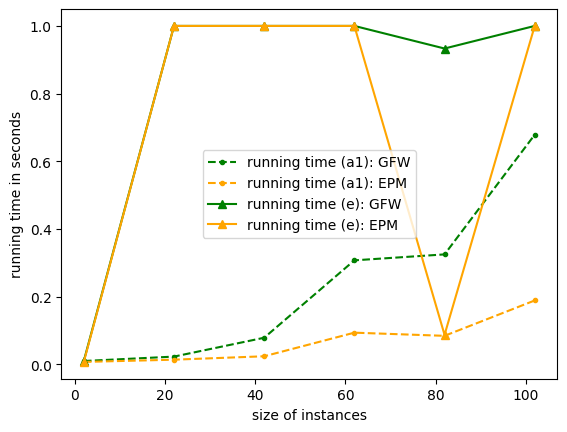

In [94]:
import matplotlib.pyplot as plt

plt.plot(x, r_y1, label='running time (a1): GFW', marker='.', color='g', linestyle='dashed')
plt.plot(x, r_z1, label='running time (a1): EPM', marker='.', color='orange', linestyle='dashed')
plt.plot(x, r_y2, label='running time (e): GFW', marker='^', color='g')
plt.plot(x, r_z2, label='running time (e): EPM', marker='^', color='orange')

plt.xlabel("size of instances")
plt.ylabel("running time in seconds")
plt.legend()
plt.show()

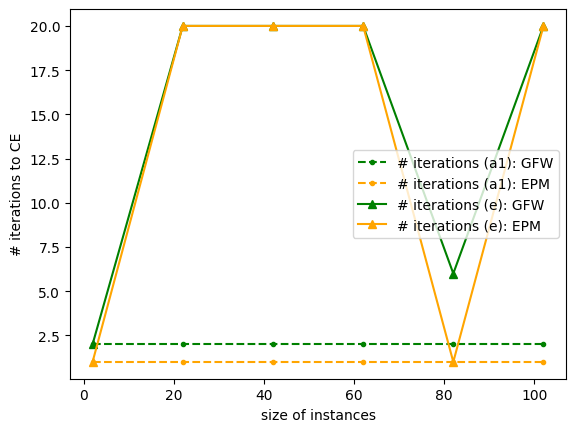

In [95]:
import matplotlib.pyplot as plt

plt.plot(x, i_y1, label='# iterations (a1): GFW', marker='.', color='g', linestyle='dashed')
plt.plot(x, i_z1, label='# iterations (a1): EPM', marker='.', color='orange', linestyle='dashed')
plt.plot(x, i_y2, label='# iterations (e): GFW', marker='^', color='g')
plt.plot(x, i_z2, label='# iterations (e): EPM', marker='^', color='orange')

plt.xlabel("size of instances")
plt.ylabel("# iterations to CE")
plt.legend()
plt.show()

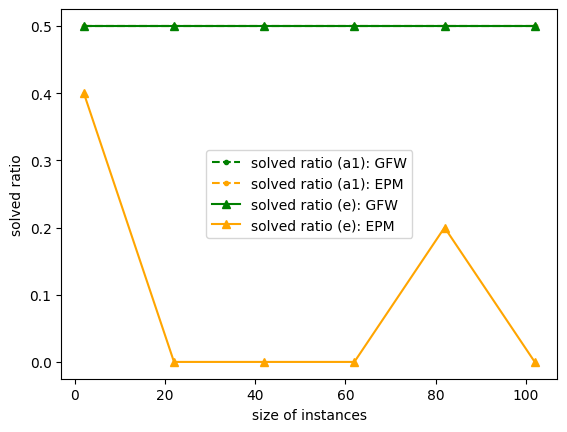

In [96]:
import matplotlib.pyplot as plt

plt.plot(x, np.array(s_y1) / 10, label='solved ratio (a1): GFW', marker='.', color='g', linestyle='dashed')
plt.plot(x, np.array(s_z1) / 10, label='solved ratio (a1): EPM', marker='.', color='orange', linestyle='dashed')
plt.plot(x, np.array(s_y2) / 10, label='solved ratio (e): GFW', marker='^', color='g')
plt.plot(x, np.array(s_z2) / 10, label='solved ratio (e): EPM', marker='^', color='orange')

plt.xlabel("size of instances")
plt.ylabel("solved ratio")
plt.legend()
plt.show()

In [4]:
"""
Experiments on AAMAS bidding data
"""

from google.colab import drive

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/chore-CEEI-experiments/bidding-data.csv')

dict_bidder_index = dict()
i = 0
for bidder in df['Bidder']:
    if bidder not in dict_bidder_index.keys():
        dict_bidder_index[bidder] = i
        i += 1

N, M = len(np.unique(df['Bidder'])), max(df['Submission'])
print(f"N = {N}, M = {M}")
B = np.ones(shape=N)

dict_pref_value = {
    'yes': 1,
    'maybe': 3,
    'no response': 5,
    'no': 7,
    'conflict': 7 * M + 1  # optimal price bound?
}

dict_pref_value_1 = {
    'yes': 0.1,
    'maybe': 1,
    'no response': 10,
    'no': 100,
    'conflict': 100 * M + 1  # optimal price bound?
}

dict_pref_value_2 = {
    'yes': 1,
    'maybe': np.sqrt(3),
    'no response': np.sqrt(5),
    'no': np.sqrt(7),
    'conflict': np.sqrt(7) * M + 1  # optimal price bound?
}

D = dict_pref_value['no response'] * np.ones(shape=(N, M))
for row in list(df.itertuples(index=False, name=None)):
    D[dict_bidder_index[row[0]]][row[1] - 1] = dict_pref_value[row[2]]

unique, counts = np.unique(D, return_counts=True)
print(unique, counts)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
N = 667, M = 526
[1.000e+00 3.000e+00 5.000e+00 3.683e+03] [  6665   6253 334979   2945]


In [106]:
def run_GFW_vs_EPM_on_bidding_data(D_):
    N, M = D_.shape
    num_LMO_list = [[], []]
    running_time_GFW_list = [[], []]
    num_ins_GFW_solved = [0, 0]
    data_GFW = {
        'size': f'{N}by{M}',
        'num-iter-a1': None,
        'num-iter-e': None,
        'solved-a1': None,
        'solved-e': None,
        'running-time-a1': None,
        'running-time-e': None,
    }
    num_QMO_list = [[], []]
    running_time_EPM_list = [[], []]
    num_ins_EPM_solved = [0, 0]
    data_EPM = {
        'size': f'{N}by{M}',
        'num-iter-a1': None,
        'num-iter-e': None,
        'solved-a1': None,
        'solved-e': None,
        'running-time-a1': None,
        'running-time-e': None,
    }

    B = np.ones(shape=N)

    '''
    Run the Greedy Frank Wolfe algorithm
    '''

    res_GFW = GFW(N, M, D_, B)
    res_EPM = EPM(N, M, D_, B, QMO_solver='GUROBI', ignore_print=True)

    for i in range(2):
        num_ins_GFW_solved[i] += res_GFW[2 + i]
        num_ins_EPM_solved[i] += res_EPM[2 + i]
        if res_GFW[2 + i] and res_EPM[2 + i]:
            num_LMO_list[i].append(res_GFW[i])
            num_QMO_list[i].append(res_EPM[i])
            running_time_GFW_list[i].append(res_GFW[4 + i])
            running_time_EPM_list[i].append(res_EPM[4 + i])

    data_GFW['num-iter-a1'] = average(num_LMO_list[0])
    data_GFW['num-iter-e'] = average(num_LMO_list[1])
    data_GFW['solved-a1'] = num_ins_GFW_solved[0]
    data_GFW['solved-e'] = num_ins_GFW_solved[1]
    data_GFW['running-time-a1'] = average(running_time_GFW_list[0])
    data_GFW['running-time-e'] = average(running_time_GFW_list[1])

    data_EPM['num-iter-a1'] = average(num_QMO_list[0])
    data_EPM['num-iter-e'] = average(num_QMO_list[1])
    data_EPM['solved-a1'] = num_ins_EPM_solved[0]
    data_EPM['solved-e'] = num_ins_EPM_solved[1]
    data_EPM['running-time-a1'] = average(running_time_EPM_list[0])
    data_EPM['running-time-e'] = average(running_time_EPM_list[1])

    print(data_GFW)
    print(data_EPM)

    return data_GFW, data_EPM

In [109]:
from sklearn.cluster import KMeans

X = D.T
clusters = KMeans(n_clusters=60, random_state=2024, n_init="auto").fit(X)

unique, counts = np.unique(clusters.labels_, return_counts=True)
print(unique, counts)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59] [  2   8   2 333   3   2   2   5   3   4   1   8   6   5   3   1   4   3
   1   2   7   5   3   7   3   3   2   1   4   8   5   4   2   3   6   3
   2   3   1   4   8   3   1   5   3   2   1   1   3   1   2   1   3   4
   2   2   3   1   3   3]


In [110]:
def get_sampled_bidding_data(D, selected_label):

    N, M = D.shape

    selected_reviewers = []
    selected_papers = []
    for j in range(M):
        if clusters.labels_[j] in selected_label:
            selected_papers.append(j)
            for i in range(N):
                if D[i][j] != 5:
                    selected_reviewers.append(i)
    selected_reviewers = np.unique(selected_reviewers)
    selected_papers = np.unique(selected_papers)
    selected_reviewers = np.random.choice(selected_reviewers, size=len(selected_papers), replace=False)
    selected_papers = np.sort(selected_papers)
    selected_reviewers = np.sort(selected_reviewers)

    print()
    print("selected papers", selected_papers)
    print("selected reviewers", selected_reviewers)

    D_sampled = D[np.ix_(selected_reviewers, selected_papers)]

    return D_sampled

In [111]:
x = list()
i_y1, i_y2 = list(), list()
i_z1, i_z2 = list(), list()
s_y1, s_y2 = list(), list()
s_z1, s_z2 = list(), list()
r_y1, r_y2 = list(), list()
r_z1, r_z2 = list(), list()

count_sorted_groups = np.argsort(counts)

# for i in range(9, 50, 10):
#     selected_label = count_sorted_groups[:i + 1]
#     D_sampled = get_sampled_bidding_data(D, selected_label=selected_label)
#     x.append(D_sampled.shape[0])
#     res_GFW_bidding_data, res_EPM_bidding_data = run_GFW_vs_EPM_on_bidding_data(D_sampled)
#     i_y1.append(res_GFW_bidding_data['num-iter-a1'])
#     s_y1.append(res_GFW_bidding_data['solved-a1'])
#     r_y1.append(res_GFW_bidding_data['running-time-a1'])
#     i_y2.append(res_GFW_bidding_data['num-iter-e'])
#     s_y2.append(res_GFW_bidding_data['solved-e'])
#     r_y2.append(res_GFW_bidding_data['running-time-e'])

#     i_z1.append(res_EPM_bidding_data['num-iter-a1'])
#     s_z1.append(res_EPM_bidding_data['solved-a1'])
#     r_z1.append(res_EPM_bidding_data['running-time-a1'])
#     i_z2.append(res_EPM_bidding_data['num-iter-e'])
#     s_z2.append(res_EPM_bidding_data['solved-e'])
#     r_z2.append(res_EPM_bidding_data['running-time-e'])


noise = np.random.uniform(size=D.shape)

res_GFW_bidding_data, res_EPM_bidding_data = run_GFW_vs_EPM_on_bidding_data(D + noise)
i_y1.append(res_GFW_bidding_data['num-iter-a1'])
s_y1.append(res_GFW_bidding_data['solved-a1'])
r_y1.append(res_GFW_bidding_data['running-time-a1'])
i_y2.append(res_GFW_bidding_data['num-iter-e'])
s_y2.append(res_GFW_bidding_data['solved-e'])
r_y2.append(res_GFW_bidding_data['running-time-e'])

i_z1.append(res_EPM_bidding_data['num-iter-a1'])
s_z1.append(res_EPM_bidding_data['solved-a1'])
r_z1.append(res_EPM_bidding_data['running-time-a1'])
i_z2.append(res_EPM_bidding_data['num-iter-e'])
s_z2.append(res_EPM_bidding_data['solved-e'])
r_z2.append(res_EPM_bidding_data['running-time-e'])

Average LP solving time: 64.37903790814536
Average QP solving time: 19.775003099441527
{'size': '667by526', 'num-iter-a1': inf, 'num-iter-e': inf, 'solved-a1': 1, 'solved-e': 1, 'running-time-a1': inf, 'running-time-e': inf}
{'size': '667by526', 'num-iter-a1': inf, 'num-iter-e': inf, 'solved-a1': 0, 'solved-e': 0, 'running-time-a1': inf, 'running-time-e': inf}
